# BP Subduction 3D - Gmsh Mesh

3D subduction zone mesh for Tandem. All lengths in **km**.

**Coordinate system**
- `x` : fault-normal, horizontal. Trench at x=0, domain spans [-Lx, +Lx]
- `y` : along-strike. Fault centred at y = along_strike/2
- `z` : depth, negative downward. Free surface at z=0

**Fault geometry**

The fault is a rectangle dipping in the x-z plane:
- Top edge (trench): x=0, z=0, y in [0, along_strike]
- Dips toward +x and -z
- Bottom edge at: x = along_dip * cos(dip), z = -along_dip * sin(dip)

The fault is split along dip into two segments:
- **RSF segment**: trench down to `depth_rsf` (rate-and-state friction)
- **Creeping segment**: `depth_rsf` down to full `along_dip`

In [2]:
import numpy as np

# Mesh resolution near the fault
Lf = 5.0          # km - target element size on the fault

# Fault dimensions
along_strike = 200.0   # km - fault extent in y
along_dip    = 150.0   # km - fault extent along the dip direction
dip          = 15.0    # degrees - dip angle from horizontal
depth_rsf    = 60.0    # km - down-dip length of the RSF segment

assert depth_rsf < along_dip, "depth_rsf must be less than along_dip"

dip_rad = np.radians(dip)

# Bounding-box tolerance for post-fragment surface queries
eps = 1e-3   # km

# Fault geometry (derived)
fault_dx     = along_dip * np.cos(dip_rad)   # km - total horizontal reach
fault_dz     = along_dip * np.sin(dip_rad)   # km - total vertical reach (positive)

# RSF segment bottom edge
rsf_dx       = depth_rsf * np.cos(dip_rad)   # km - horizontal reach of RSF segment
rsf_dz       = depth_rsf * np.sin(dip_rad)   # km - vertical reach of RSF segment

print(f"Fault dip:            {dip} deg")
print(f"Along strike:         {along_strike} km")
print(f"Along dip:            {along_dip} km")
print(f"RSF segment:          0 to {depth_rsf} km down-dip")
print(f"Creeping segment:     {depth_rsf} to {along_dip} km down-dip")
print()
print(f"Trench (top edge):    x=0,            z=0")
print(f"RSF bottom edge:      x={rsf_dx:.1f},   z={-rsf_dz:.1f} km")
print(f"Fault bottom edge:    x={fault_dx:.1f},  z={-fault_dz:.1f} km")

Fault dip:            15.0 deg
Along strike:         200.0 km
Along dip:            150.0 km
RSF segment:          0 to 60.0 km down-dip
Creeping segment:     60.0 to 150.0 km down-dip

Trench (top edge):    x=0,            z=0
RSF bottom edge:      x=58.0,   z=-15.5 km
Fault bottom edge:    x=144.9,  z=-38.8 km


## Fault geometry visualization

Quick sanity check before building any Gmsh objects.
The fault dips in the **x-z plane**: the trench sits at x=0, z=0
and the fault bottom edge is at x=fault_dx, z=-fault_dz.

The coordinate axes show the orientation:
- **x** (red)  : fault-normal, horizontal. Positive = away from trench into overriding plate
- **y** (green): along-strike. Fault centred at y=0
- **z** (blue) : vertical. Positive = up, z=0 is the free surface

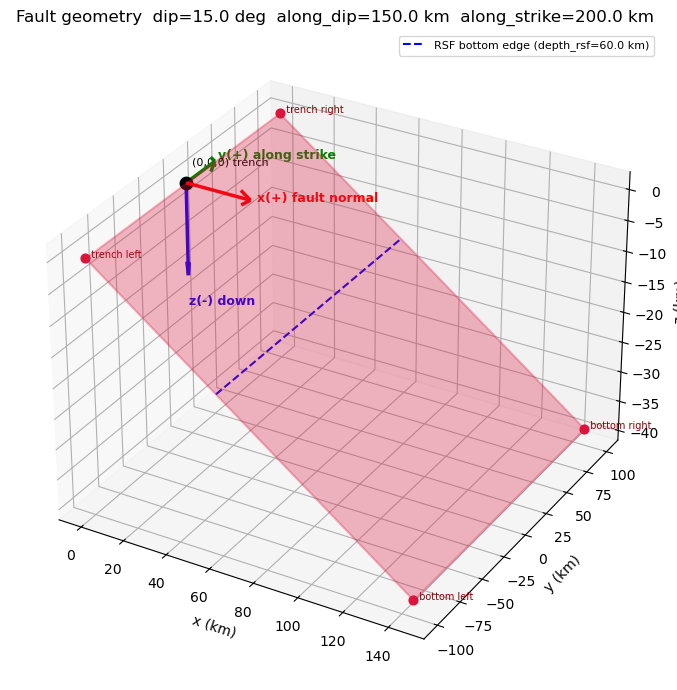

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

# Fault rectangle corners
corners = [
    [0,        -along_strike/2,  0        ],   # trench left
    [0,        +along_strike/2,  0        ],   # trench right
    [fault_dx, +along_strike/2, -fault_dz ],   # bottom right
    [fault_dx, -along_strike/2, -fault_dz ],   # bottom left
]

# Shade the fault surface
fault_poly = Poly3DCollection([corners], alpha=0.3,
                               facecolor='crimson', edgecolor='crimson', linewidth=1.5)
ax.add_collection3d(fault_poly)

# Draw RSF segment bottom edge (dashed line across strike)
ax.plot([rsf_dx, rsf_dx], [-along_strike/2, +along_strike/2], [-rsf_dz, -rsf_dz],
        'b--', linewidth=1.5, label=f'RSF bottom edge (depth_rsf={depth_rsf} km)')

# Label fault corners
for (x, y, z), label in zip(corners, ['trench left', 'trench right', 'bottom right', 'bottom left']):
    ax.scatter(x, y, z, color='crimson', s=40, zorder=5)
    ax.text(x, y, z, '  ' + label, fontsize=7, color='darkred')

# Coordinate axes from origin
L = 30
ax.quiver(0, 0, 0,  L,    0,     0,    color='red',   arrow_length_ratio=0.15, linewidth=2.5)
ax.quiver(0, 0, 0,  0,    L,     0,    color='green', arrow_length_ratio=0.15, linewidth=2.5)
ax.quiver(0, 0, 0,  0,    0,    -L/2,  color='blue',  arrow_length_ratio=0.15, linewidth=2.5)
ax.text(L+3, 0,    0,    'x(+) fault normal', color='red',   fontsize=9, fontweight='bold')
ax.text(0,   L+3,  0,    'y(+) along strike', color='green', fontsize=9, fontweight='bold')
ax.text(0,   0,   -20,   'z(-) down',         color='blue',  fontsize=9, fontweight='bold')

# Mark origin
ax.scatter(0, 0, 0, color='black', s=80, zorder=10)
ax.text(3, 0, 3, '(0,0,0) trench', fontsize=8, color='black')

ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_zlabel('z (km)')
ax.set_title('Fault geometry  dip=' + str(dip) + ' deg  along_dip=' + str(along_dip) + ' km  along_strike=' + str(along_strike) + ' km')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Fault rectangle

Build the fault as a flat planar surface with 4 corners.

| Point | x | y | z |
|-------|---|---|---|
| trench left  | 0 | -along_strike/2 | 0 |
| trench right | 0 | +along_strike/2 | 0 |
| bottom right | fault_dx | +along_strike/2 | -fault_dz |
| bottom left  | fault_dx | -along_strike/2 | -fault_dz |

The four lines are:
- `l_trench` : top edge, along y (the trench)
- `l_dip_right` / `l_dip_left` : the two down-dip edges
- `l_bottom` : bottom edge, along y

In [4]:
import gmsh

gmsh.initialize()
gmsh.model.add('bp_subduction_3d')
gmsh.option.setNumber("General.Terminal", 0)

# Four corners of the fault rectangle
pt_trench_left  = gmsh.model.occ.addPoint(0,         -along_strike/2,  0)
pt_trench_right = gmsh.model.occ.addPoint(0,         +along_strike/2,  0)
pt_bottom_right = gmsh.model.occ.addPoint(fault_dx,  +along_strike/2, -fault_dz)
pt_bottom_left  = gmsh.model.occ.addPoint(fault_dx,  -along_strike/2, -fault_dz)

# Edges
l_trench     = gmsh.model.occ.addLine(pt_trench_left,  pt_trench_right)  # top edge
l_dip_right  = gmsh.model.occ.addLine(pt_trench_right, pt_bottom_right)  # right dip edge
l_bottom     = gmsh.model.occ.addLine(pt_bottom_right, pt_bottom_left)   # bottom edge
l_dip_left   = gmsh.model.occ.addLine(pt_bottom_left,  pt_trench_left)   # left dip edge

loop_fault   = gmsh.model.occ.addCurveLoop([l_trench, l_dip_right, l_bottom, l_dip_left])
fault_surf   = gmsh.model.occ.addPlaneSurface([loop_fault])

gmsh.model.occ.synchronize()

print(f"fault_surf tag: {fault_surf}")
bb = gmsh.model.getBoundingBox(2, fault_surf)
print(f"x: [{bb[0]:.2f}, {bb[3]:.2f}]  (expected [0, {fault_dx:.2f}])")
print(f"y: [{bb[1]:.2f}, {bb[4]:.2f}]  (expected [{-along_strike/2:.1f}, {along_strike/2:.1f}])")
print(f"z: [{bb[2]:.2f}, {bb[5]:.2f}]  (expected [{-fault_dz:.2f}, 0])")

fault_surf tag: 1
x: [-0.00, 144.89]  (expected [0, 144.89])
y: [-100.00, 100.00]  (expected [-100.0, 100.0])
z: [-38.82, 0.00]  (expected [-38.82, 0])


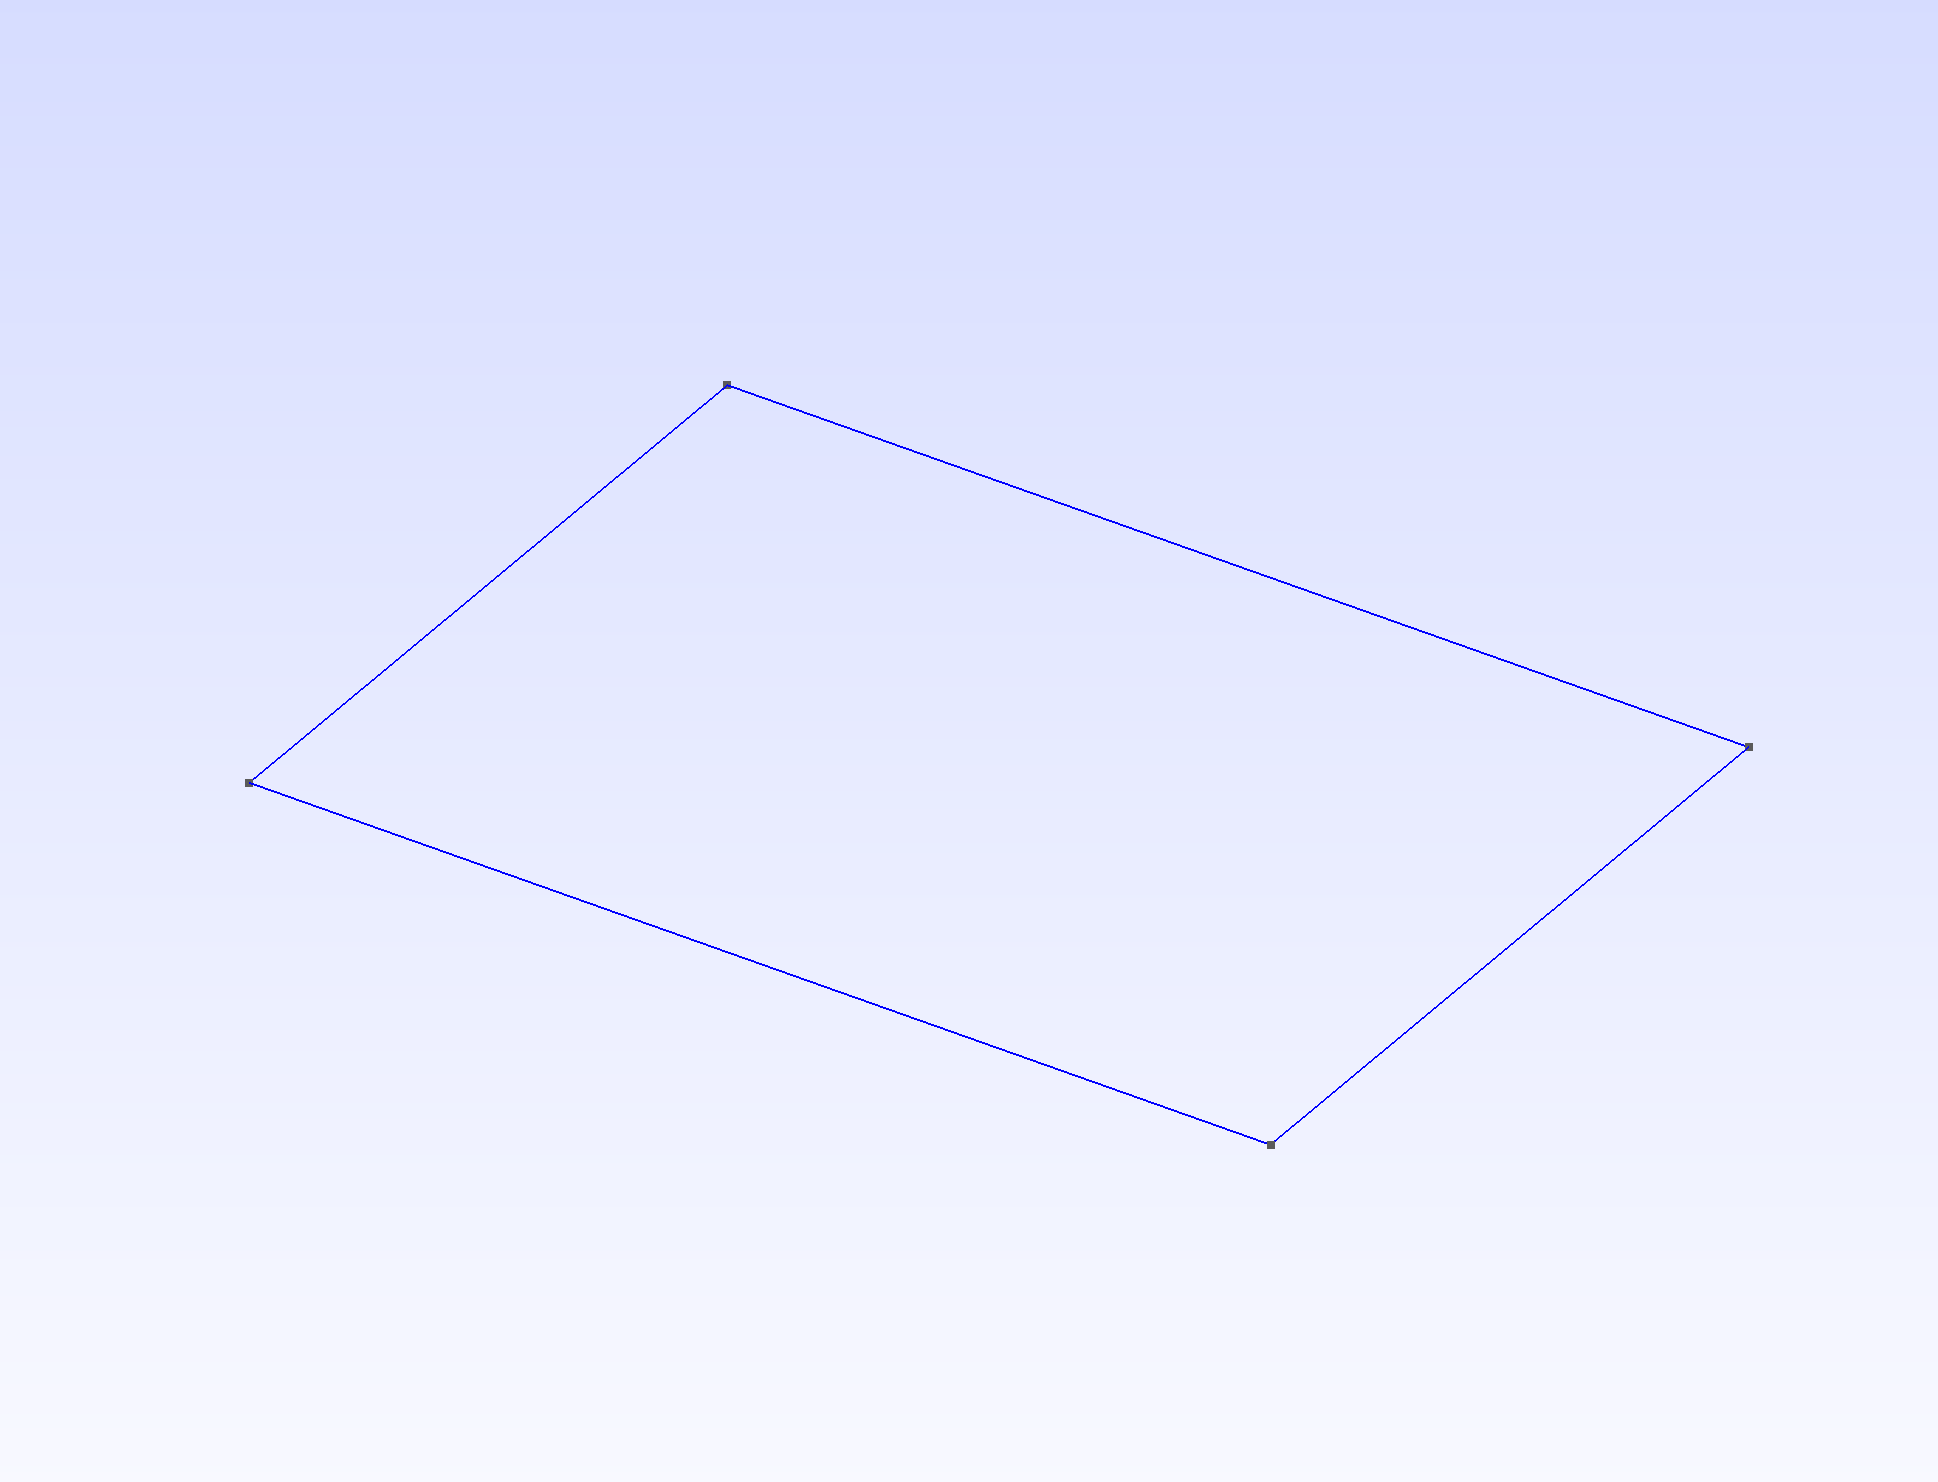

In [5]:
from IPython.display import Image, display
display(Image('SC/1_surface.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

## Domain box

The box is fully defined by the fault geometry:

| dimension | from | to |
|-----------|------|----|
| x | -fault_dx | +fault_dx |
| y | -along_strike/2 | +along_strike/2 |
| z | -fault_dz | 0 |

In [6]:
domain_box = gmsh.model.occ.addBox(
    -fault_dx,       -along_strike/2,  -fault_dz,
     2 * fault_dx,    along_strike,     fault_dz
)

gmsh.model.occ.synchronize()

print(f"domain_box tag: {domain_box}")
bb = gmsh.model.getBoundingBox(3, domain_box)
print(f"x: [{bb[0]:.2f}, {bb[3]:.2f}]")
print(f"y: [{bb[1]:.2f}, {bb[4]:.2f}]")
print(f"z: [{bb[2]:.2f}, {bb[5]:.2f}]")

domain_box tag: 1
x: [-144.89, 144.89]
y: [-100.00, 100.00]
z: [-38.82, 0.00]


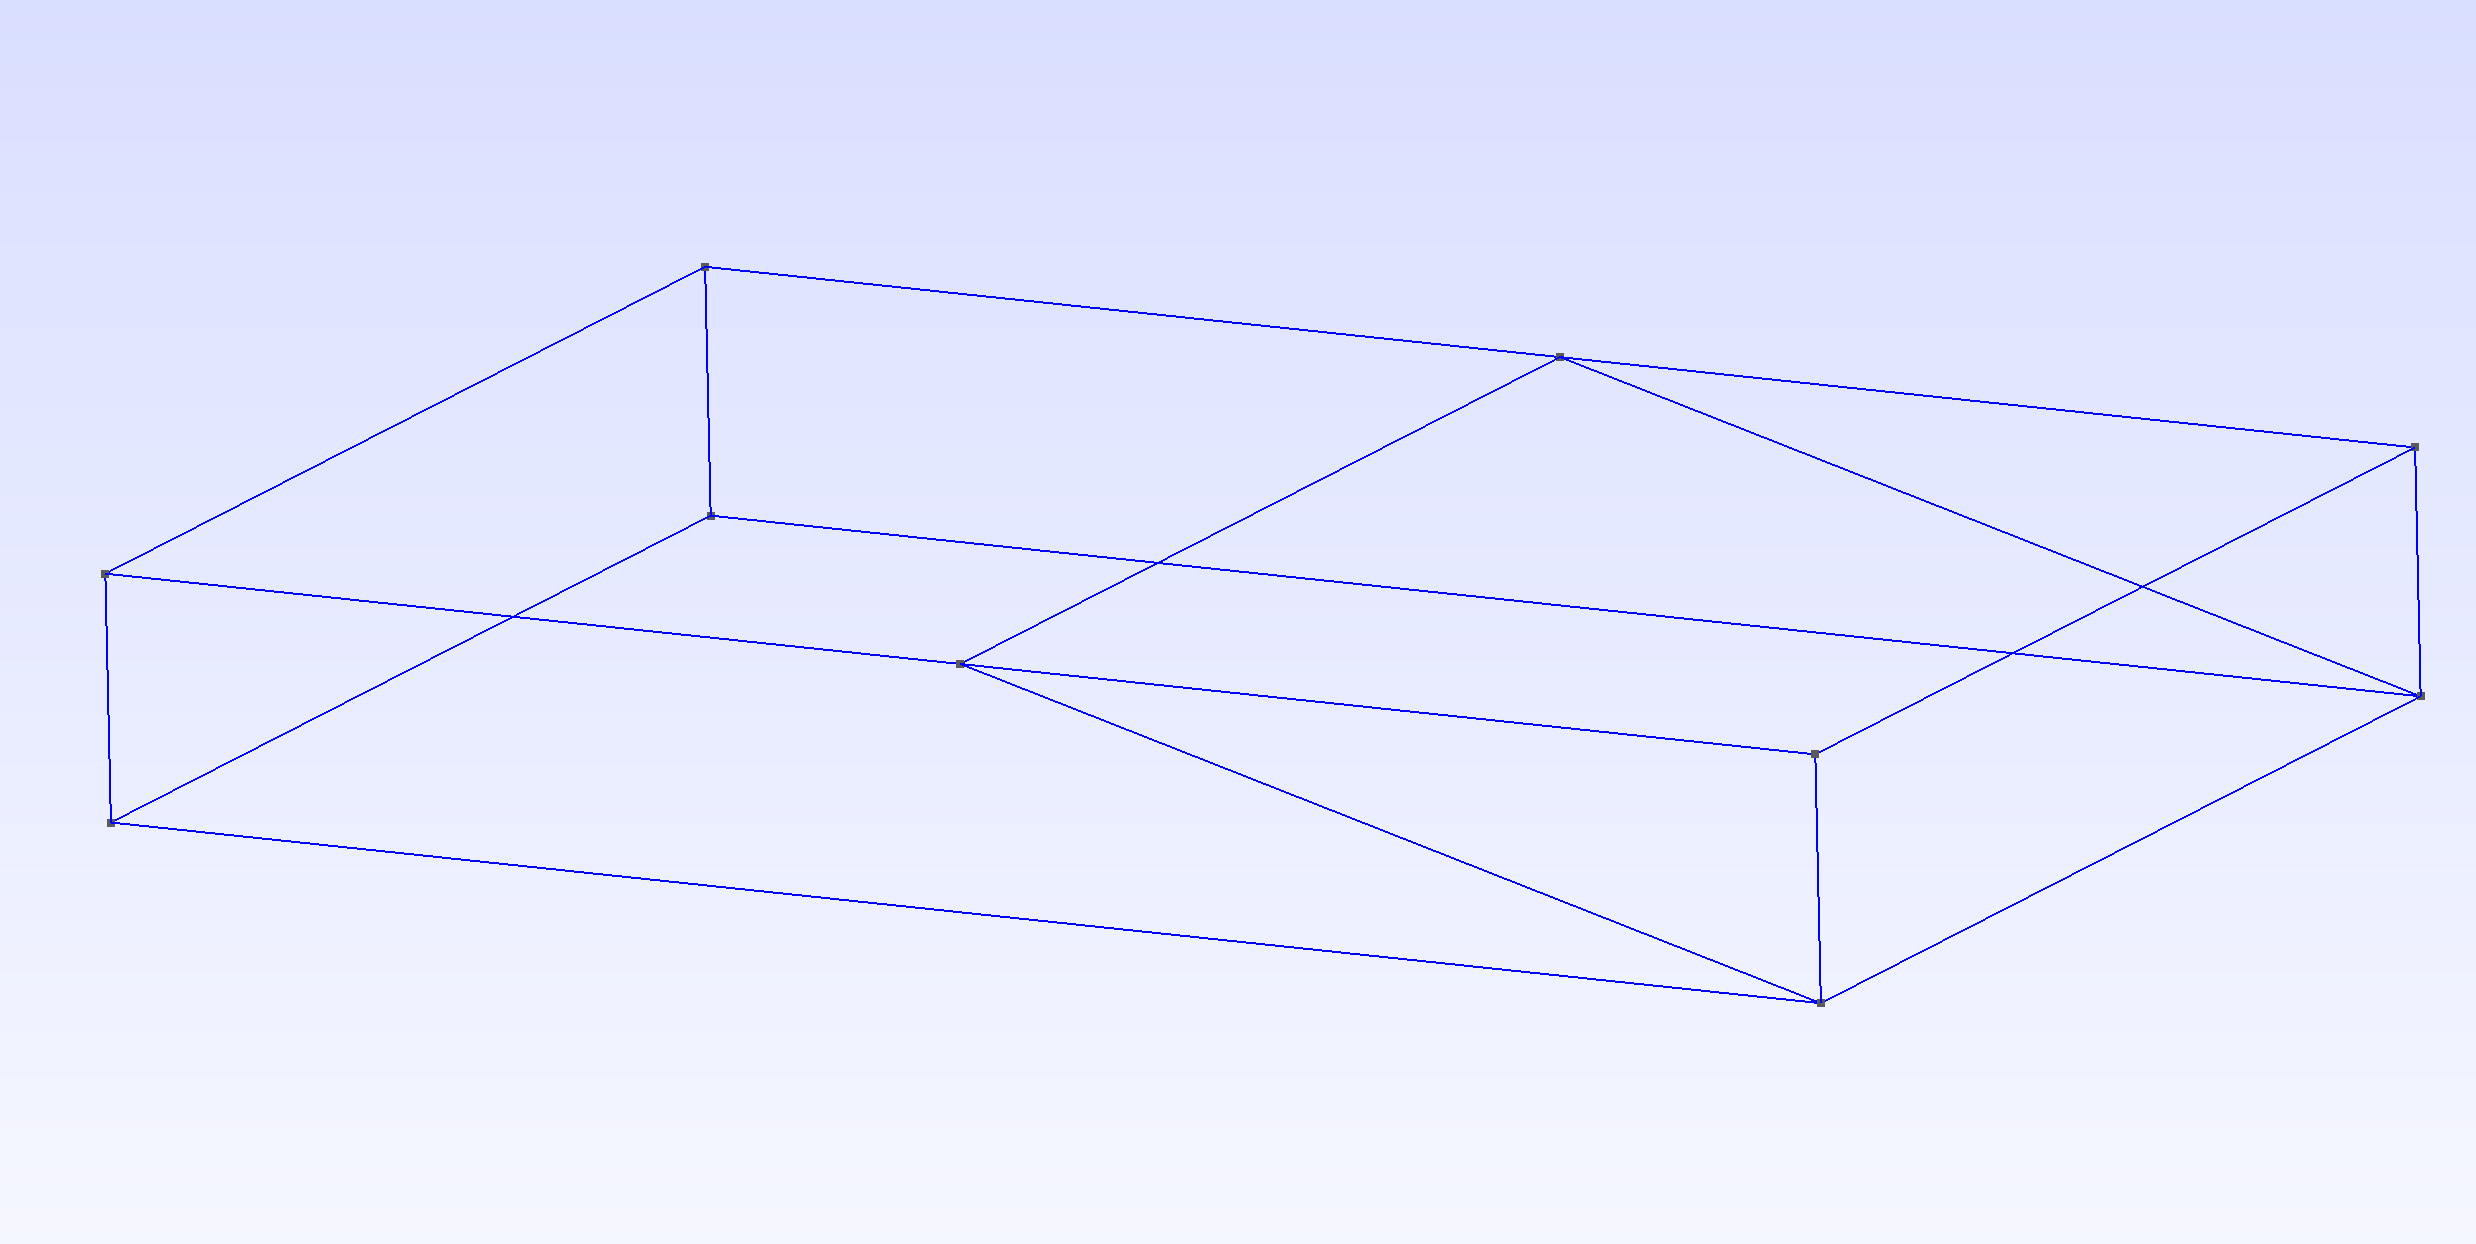

In [8]:
from IPython.display import Image, display
display(Image('SC/domain.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

## BooleanFragments

`fragment(tool, object)` cuts the tool with the object and returns two things:
- `out`     : list of (dim, tag) for all surviving entities
- `out_map` : maps each INPUT entity to the outputs it became.
  Input order is [tool, object], so:
  - `out_map[0]` -> what the domain box became (the two plate volumes)
  - `out_map[1]` -> what the fault surface became (the fault interface)

This is the clean way to grab the fault: we ask the fragment directly which
output came from the fault surface, instead of guessing by bounding box.

To tell the upper plate from the lower plate we use the **center of mass**.
The upper plate (overriding wedge) has its centroid on the x < 0 side; the
lower plate (subducting slab) has its centroid on the x > 0 side. This is a
physical, unambiguous separator with no magic tolerances.

In [9]:
# --- BooleanFragments ---
# fragment(tool, object) returns (out, out_map).
# out_map mirrors the order of the inputs:
#   out_map[0] -> what the 1st argument (domain_box) became  -> the two plate volumes
#   out_map[1] -> what the 2nd argument (fault_surf) became  -> the fault interface
# Each entry is a list of (dim, tag) pairs:
#   dim=3 -> volume, dim=2 -> surface, dim=1 -> curve
out, out_map = gmsh.model.occ.fragment([(3, domain_box)], [(2, fault_surf)])
gmsh.model.occ.synchronize()

# --- Fault surface ---
# out_map[1] is what fault_surf (2nd arg) became after the fragment.
# It should be exactly one surface (dim=2). If not, the geometry went wrong.
fault_frags = out_map[1]
if len(fault_frags) != 1 or fault_frags[0][0] != 2:
    raise ValueError(
        f"Expected fault_surf to fragment into exactly 1 surface, "
        f"got: {fault_frags}"
    )
fault_tag = fault_frags[0][1]   # fault_frags[0] = (dim, tag) -> [1] gives the tag

# --- Upper / lower plate ---
# out_map[0] is what domain_box (1st arg) became -> the two plate volumes.
# getCenterOfMass(dim, tag) returns (x, y, z) of the centroid assuming uniform density.
# [0]=x, [1]=y, [2]=z
# The fault dips toward +x. The upper plate (overriding plate) sits ABOVE the fault:
#   it occupies the wedge on the x > 0 side where the fault dips under it.
#   Its centroid is at x > 0.
# The lower plate (subducting slab) goes UNDER the fault:
#   it spans both sides but its centroid is at x < 0.
# Print both centroids first so we can verify the split.
plate_volumes = [t for d, t in out_map[0]]
print("Center of mass for each plate volume:")
for t in plate_volumes:
    com = gmsh.model.occ.getCenterOfMass(3, t)
    print(f"  Volume {t}: x={com[0]:.2f}, y={com[1]:.2f}, z={com[2]:.2f}")

upper_plate = None
lower_plate = None
for t in plate_volumes:
    com_x = gmsh.model.occ.getCenterOfMass(3, t)[0]
    if com_x > 0:
        upper_plate = t   # overriding plate: centroid at x > 0
    else:
        lower_plate = t   # subducting slab:  centroid at x < 0

print(f"\nupper_plate volume: {upper_plate}")
print(f"lower_plate volume: {lower_plate}")
print(f"fault surface tag:  {fault_tag}")

Center of mass for each plate volume:
  Volume 1: x=-32.20, y=-0.00, z=-21.57
  Volume 2: x=96.59, y=0.00, z=-12.94

upper_plate volume: 2
lower_plate volume: 1
fault surface tag:  1


## Split the fault into RSF and creeping segments

The fault is split along-dip at `depth_rsf` into two surfaces:
- **RSF segment**: from the trench down to `depth_rsf` (rate-and-state friction)
- **Creeping segment**: from `depth_rsf` down to the fault bottom (prescribed/dislocation)

The split is done by embedding a line at `(rsf_dx, :, -rsf_dz)` into the fault surface
using another `BooleanFragments`. Same `out_map` pattern as before:
- `out_map[0]` -> what the fault surface became (the two segments)
- `out_map[1]` -> what the split line became (the shared edge)

The two segments are identified by center-of-mass x:
- RSF segment: closer to trench, com_x < rsf_dx
- Creeping segment: deeper, com_x > rsf_dx

In [10]:
# Split line runs across the full strike at the RSF bottom edge
p_split_left  = gmsh.model.occ.addPoint(rsf_dx, -along_strike/2, -rsf_dz)
p_split_right = gmsh.model.occ.addPoint(rsf_dx, +along_strike/2, -rsf_dz)
split_line    = gmsh.model.occ.addLine(p_split_left, p_split_right)

# Fragment the fault surface with the split line
# out_map[0] -> fault_tag became these two surfaces
# out_map[1] -> split_line became this edge (shared between the two segments)
out_split, out_map_split = gmsh.model.occ.fragment([(2, fault_tag)], [(1, split_line)])
gmsh.model.occ.synchronize()

# Two fault segments from out_map_split[0]
fault_segs = [t for d, t in out_map_split[0]]
if len(fault_segs) != 2:
    raise ValueError(f"Expected 2 fault segments, got: {fault_segs}")

# Identify by center-of-mass x:
#   RSF segment:      com_x < rsf_dx  (shallow, close to trench)
#   Creeping segment: com_x > rsf_dx  (deep, below RSF)
rsf_surf      = None
creeping_surf = None
for t in fault_segs:
    com_x = gmsh.model.occ.getCenterOfMass(2, t)[0]
    print(f"  Surface {t}: com_x={com_x:.1f}")
    if com_x < rsf_dx:
        rsf_surf = t
    else:
        creeping_surf = t

print(f"\nrsf_surf:      {rsf_surf}")
print(f"creeping_surf: {creeping_surf}")

  Surface 11: com_x=29.0
  Surface 12: com_x=101.4

rsf_surf:      11
creeping_surf: 12


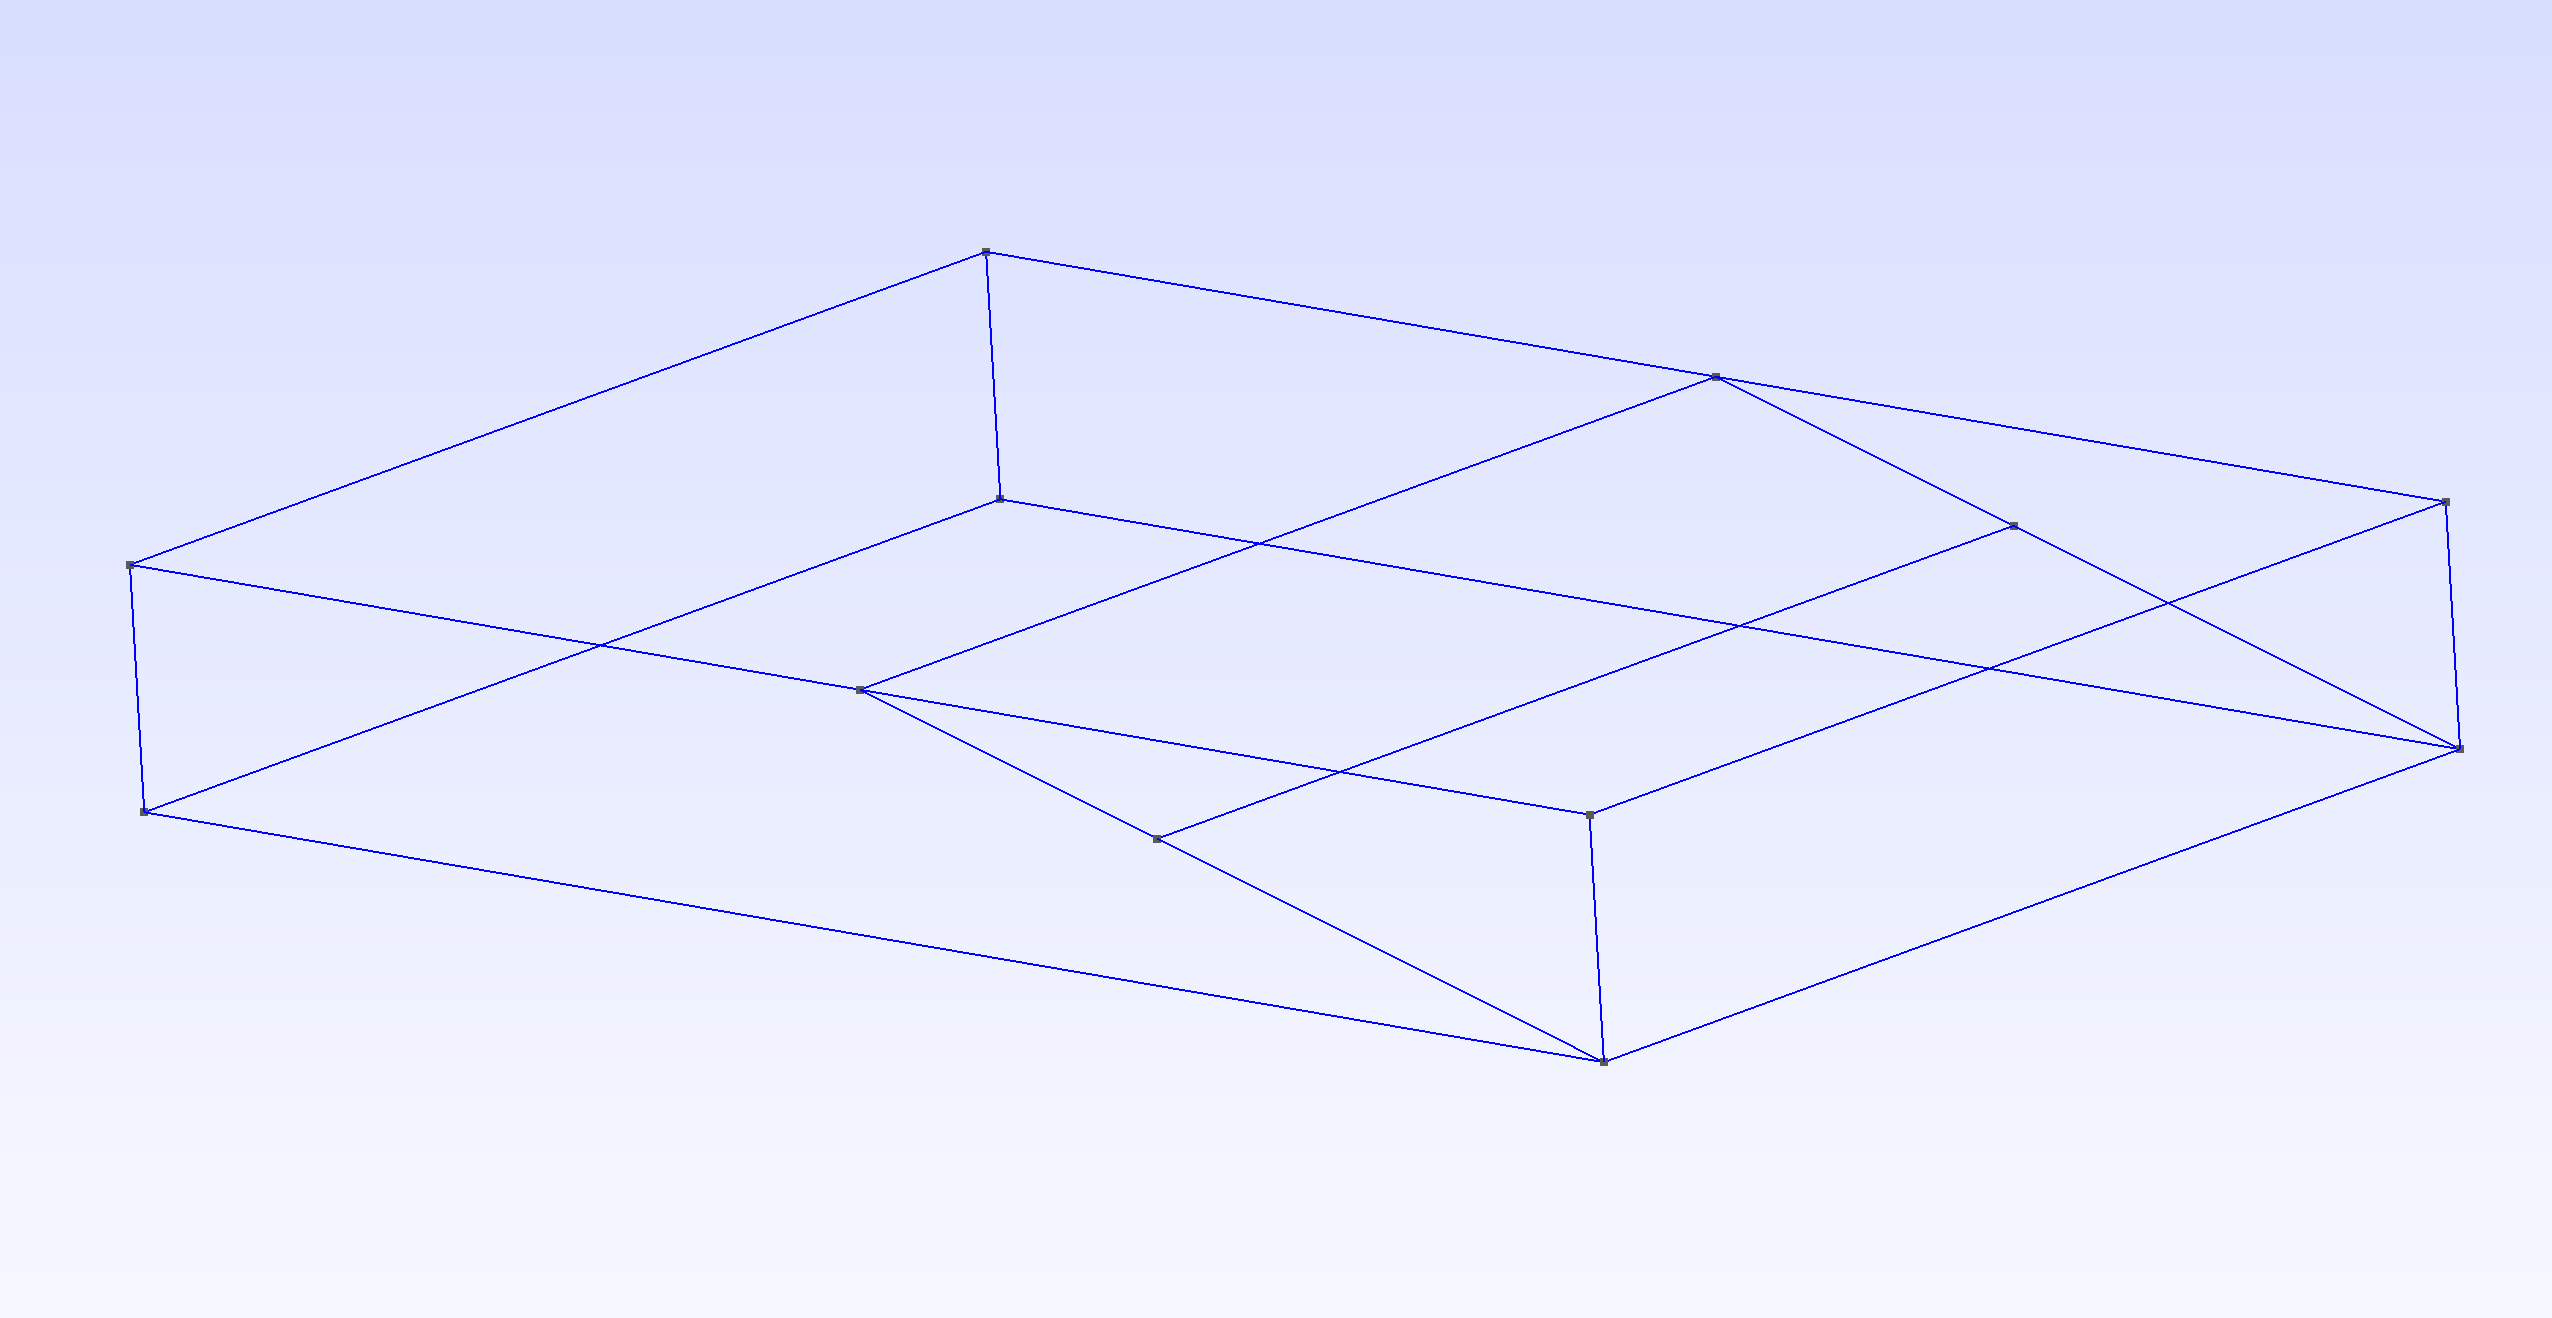

In [11]:
from IPython.display import Image, display
display(Image('SC/domain_fault_splitted.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

## Physical groups

Assign the boundary condition tags Tandem reads from the `.msh` file.

| Tag | What | Description |
|-----|------|-------------|
| 1   | all walls except rsf and creeping | Free surface (zero traction) |
| 3   | rsf_surf | Rate-and-state friction |
| 5   | creeping_surf | Dirichlet / prescribed dislocation |

The free surfaces are simply everything that is not the fault:
all surfaces minus the two fault segments.

In [12]:
FREE_TAG      = 1
RSF_TAG       = 3
DIRICHLET_TAG = 5

# Free surfaces: everything except the two fault segments
all_surfs = set(t for _, t in gmsh.model.getEntities(dim=2))
free_tags = sorted(all_surfs - {rsf_surf, creeping_surf})

# Surfaces (dim=2)
gmsh.model.addPhysicalGroup(2, free_tags,       tag=FREE_TAG,      name="free")
gmsh.model.addPhysicalGroup(2, [rsf_surf],      tag=RSF_TAG,       name="rsf_fault")
gmsh.model.addPhysicalGroup(2, [creeping_surf], tag=DIRICHLET_TAG, name="creeping")

# Volumes (dim=3)
upper_plate_phys = gmsh.model.addPhysicalGroup(3, [upper_plate], name="upper_plate")
lower_plate_phys = gmsh.model.addPhysicalGroup(3, [lower_plate], name="lower_plate")

print(f"Physical Surface({FREE_TAG})  = {free_tags}  <- free")
print(f"Physical Surface({RSF_TAG})  = [{rsf_surf}]             <- RSF fault")
print(f"Physical Surface({DIRICHLET_TAG})  = [{creeping_surf}]            <- creeping (Dirichlet)")
print(f"Physical Volume  = upper_plate({upper_plate_phys}), lower_plate({lower_plate_phys})")

Physical Surface(1)  = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  <- free
Physical Surface(3)  = [11]             <- RSF fault
Physical Surface(5)  = [12]            <- creeping (Dirichlet)
Physical Volume  = upper_plate(6), lower_plate(7)


## Mesh size fields

Three gmsh controls are disabled first so element size comes entirely
from the background field:

```python
Mesh.CharacteristicLengthExtendFromBoundary = 0
Mesh.CharacteristicLengthFromPoints         = 0
Mesh.CharacteristicLengthFromCurvature      = 0
```

Two fields drive the mesh size:

**Field 1 - Distance from the RSF fault surface**
Computes 3D distance from every point in the domain to the RSF fault surface.

**Field 2 - Threshold**
- From 0 to `dist_min`: element size = `Lf` (fine, on the fault)
- From `dist_min` to `dist_max`: grows linearly from `Lf` to `Lc`
- Beyond `dist_max`: element size = `Lc` (coarse, far from fault)

```
h
Lc  __|_______
    /
Lf_|
   |----|----|----> distance
   0  dmin  dmax
```

In [13]:
# Disable automatic size hints from geometry
gmsh.option.setNumber('Mesh.CharacteristicLengthExtendFromBoundary', 0)
gmsh.option.setNumber('Mesh.CharacteristicLengthFromPoints',          0)
gmsh.option.setNumber('Mesh.CharacteristicLengthFromCurvature',       0)

Lc       = 20.0    # km - max element size far from the fault
dist_min =  0.0    # km - fine zone: keep Lf up to this distance from fault
dist_max = 80.0    # km - coarse zone: fully at Lc beyond this distance

# Field 1: distance from the RSF fault surface
field_dist = gmsh.model.mesh.field.add('Distance')
gmsh.model.mesh.field.setNumbers(field_dist, 'FacesList', [rsf_surf])

# Field 2: Threshold - Lf at fault, linear growth, caps at Lc
field_thresh = gmsh.model.mesh.field.add('Threshold')
gmsh.model.mesh.field.setNumber(field_thresh, 'InField',   field_dist)
gmsh.model.mesh.field.setNumber(field_thresh, 'SizeMin',   Lf)
gmsh.model.mesh.field.setNumber(field_thresh, 'SizeMax',   Lc)
gmsh.model.mesh.field.setNumber(field_thresh, 'DistMin',   dist_min)
gmsh.model.mesh.field.setNumber(field_thresh, 'DistMax',   dist_max)

gmsh.model.mesh.field.setAsBackgroundMesh(field_thresh)

print(f"h = {Lf} km  from d=0 to d={dist_min} km")
print(f"h grows linearly from {Lf} to {Lc} km  between d={dist_min} and d={dist_max} km")
print(f"h = {Lc} km  beyond d={dist_max} km")

h = 5.0 km  from d=0 to d=0.0 km
h grows linearly from 5.0 to 20.0 km  between d=0.0 and d=80.0 km
h = 20.0 km  beyond d=80.0 km


## Generate and export

Generate a full 3D tetrahedral mesh and write it as a v2.2 `.msh` file.
Tandem requires v2.2.

In [14]:
gmsh.option.setNumber('Mesh.MshFileVersion', 2.2)

gmsh.model.mesh.generate(3)
gmsh.write('bp_subduction_3d.msh')

gmsh.finalize()
print("Mesh written to bp_subduction_3d.msh")

Mesh written to bp_subduction_3d.msh


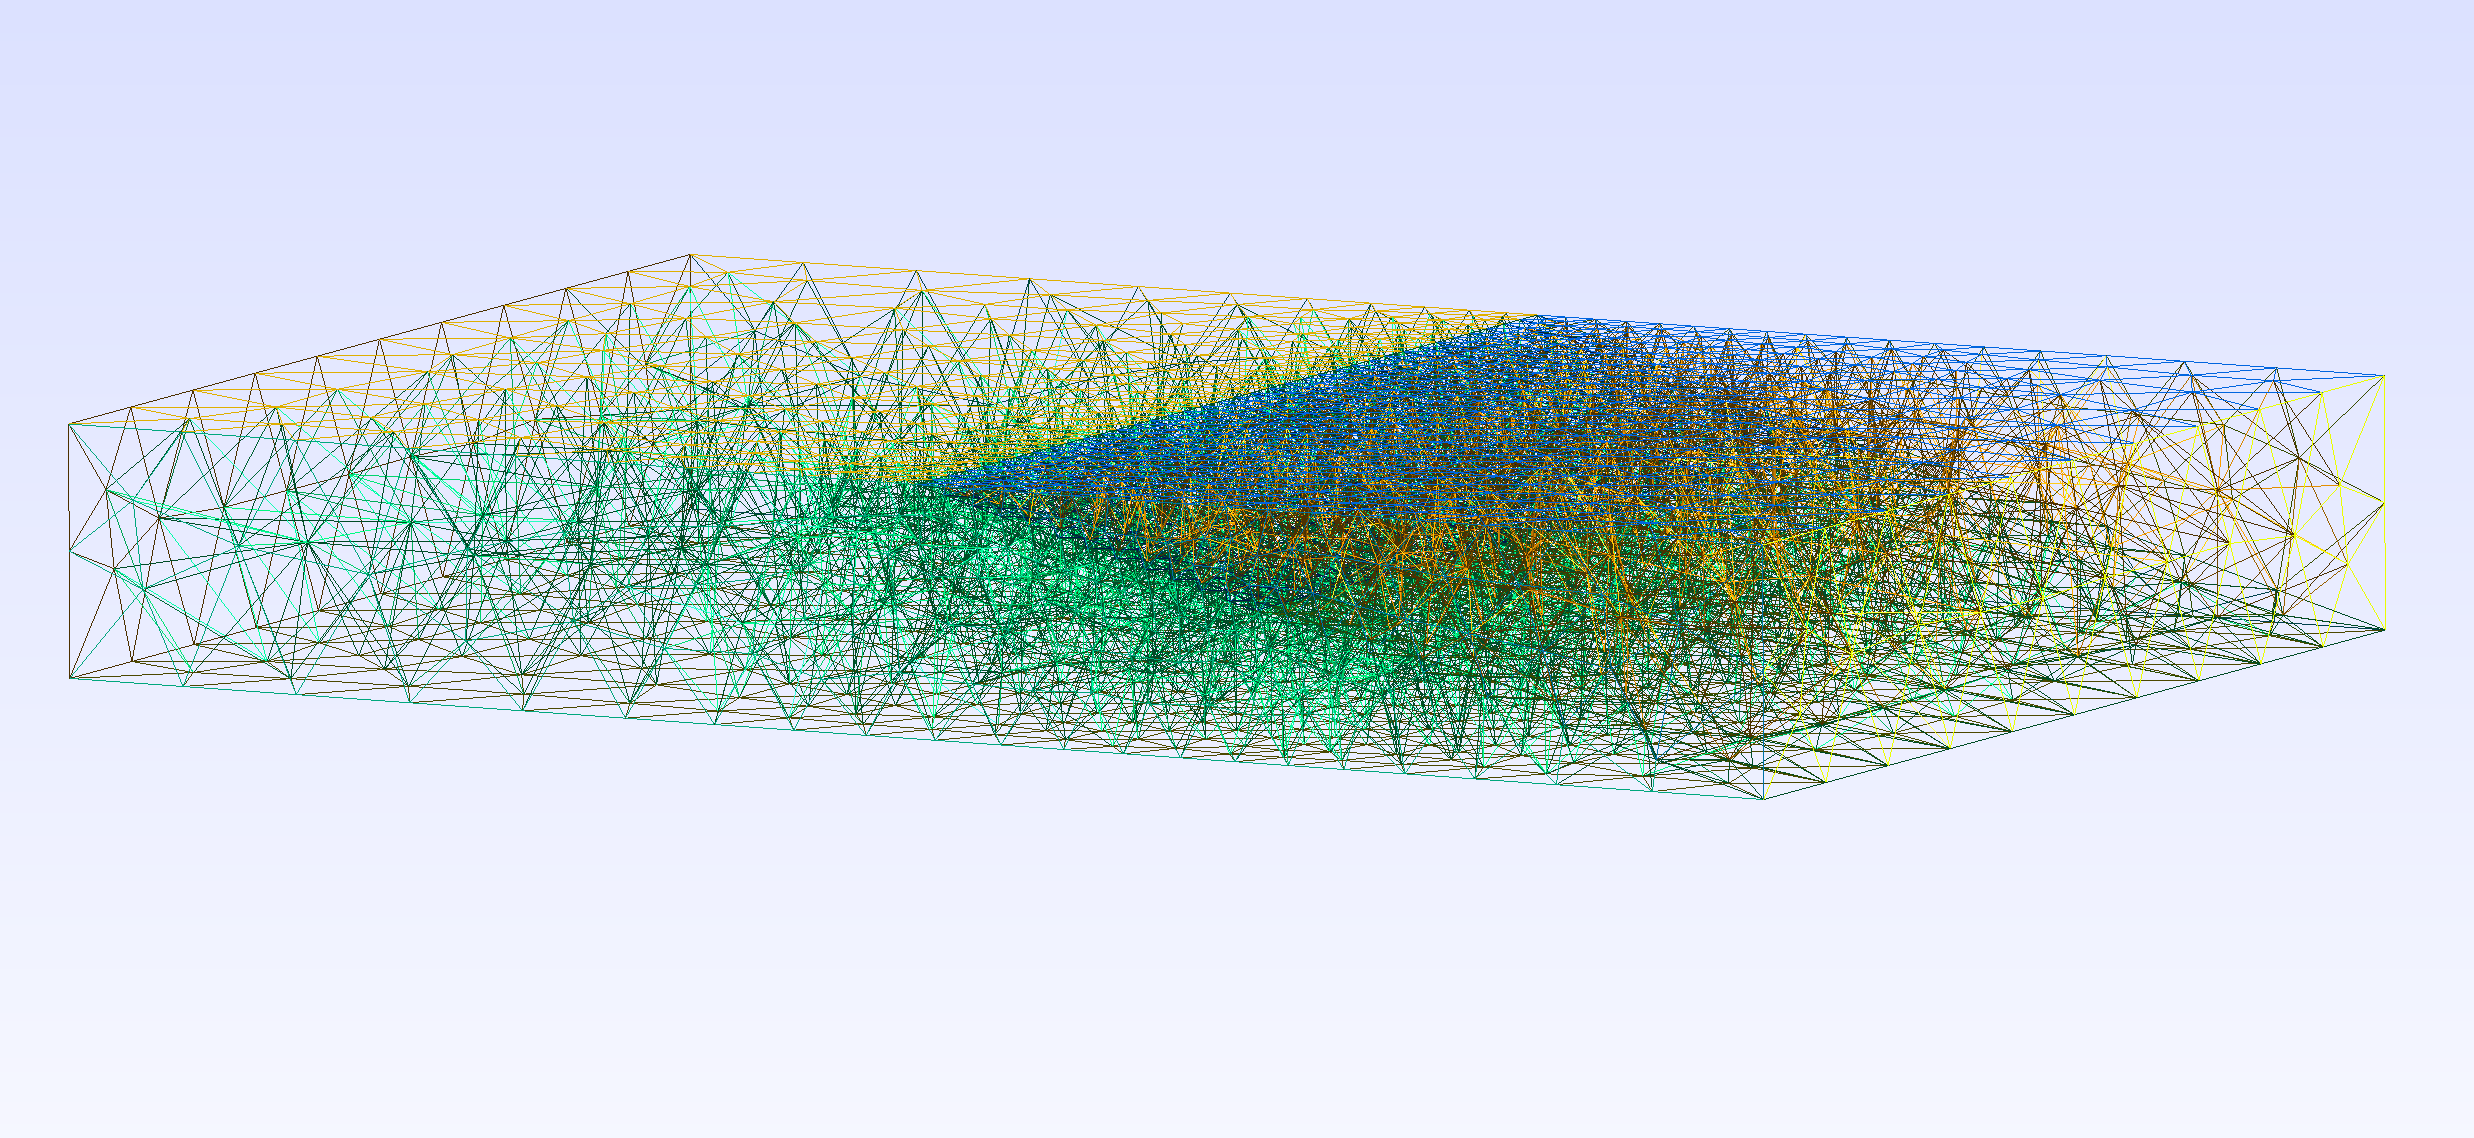

In [15]:
from IPython.display import Image, display
display(Image('SC/final_mesh.png'))

# If you were running locally, you could open the Gmsh GUI with:
# gmsh.fltk.run()
# This won't work here because we are on a remote server with no display.

## Verify mesh

Load the exported mesh with `GmshMesh3D` and check that all physical groups
have the right tags and element counts before running Tandem.

`GmshMesh3D` accepts:
- `surface_tags` : list of physical surface IDs to show (default: all)
- `volume_tags`  : list of physical volume IDs to show (default: all)
- `show_mesh`    : show triangle/tet edges (default: True)
- `opacity_surface` / `opacity_volume` : control transparency

In [18]:
from domainOutput3D import GmshMesh3D

mesh3d = GmshMesh3D('bp_subduction_3d.msh')
mesh3d.summary()


File: bp_subduction_3d.msh
Points: 3688

Surface groups (dim=2):
  tag=1  n_triangles=  4299  name='free'
  tag=3  n_triangles=   960  name='rsf_fault'
  tag=5  n_triangles=   429  name='creeping'

Volume groups (dim=3):
  tag=6  n_tets=  4706  name='upper_plate'
  tag=7  n_tets=  9012  name='lower_plate'


In [19]:
# Plot all surfaces coloured by physical group, volumes transparent
pl = mesh3d.plot(
    surface_tags = [1, 3, 5],   # free, rsf_fault, creeping
    volume_tags  = [6, 7],      # upper_plate, lower_plate
    show_mesh    = True,
    opacity_surface = 0.9,
    opacity_volume  = 0.2,
)
pl.show()

Widget(value='<iframe src="http://localhost:62763/index.html?ui=P_0x11b615900_0&reconnect=auto" class="pyvista…

In [20]:
# Fault surfaces only - no volumes, no mesh edges
pl = mesh3d.plot(
    surface_tags = [3, 5],   # rsf_fault and creeping only
    volume_tags  = [],
    show_mesh    = False,
    opacity_surface = 1.0,
)
pl.show()

Widget(value='<iframe src="http://localhost:62763/index.html?ui=P_0x30454d630_1&reconnect=auto" class="pyvista…

# Try on Your Own

### 1. Dipping side walls

The current domain has flat vertical side walls. The goal is a domain whose left
and right walls are parallel to the fault plane, so the perpendicular distance
from the fault to the boundary is constant everywhere.

Create a bigger axis-aligned box, cut it with two tilted planes parallel to the
fault, and remove the two outer volumes with
`gmsh.model.occ.remove([(3, tag)], recursive=True)`.

> **Tip**: The offset from the fault to each cutting plane in x and z is
> `(d * sin(dip), d * cos(dip))`, not `(d, 0)`.

### 2. Different resolution per segment

Currently only the RSF fault drives mesh refinement. The goal is independent
control over element size near the RSF segment and near the creeping segment.

Add a second `Threshold` field driven by `creeping_surf`, then combine both
with a `Min` field and set that as the background mesh.

> **Tip**: The `Min` field picks the finest size from all its inputs at every
> point in the domain — you can stack as many `Threshold` fields as you need.